# SAFOD DAS + repeaters: decision checkpoint

**Decision: proceed to the nonblind development scan.**

This clean-room checkpoint has found a defensible project, but not yet a DAS catalog extension. The most interesting result is a genuine published-catalog disagreement next to a unique near-source DAS experiment: exact shared event IDs split the old target across Michel M00413 and M00414, while Michel M00414 merges events that Waldhauser--Schaff separates. The conventional array does not resolve that partition cleanly.

A second, independent opportunity is the 2026 event recorded on the deep fiber. Event 75336682 passes the frozen conventional-network verifier and is strongly visible on deep DAS; same-fiber control 75343317 fails. The family name is provisional until the catalog partition is reconciled.

This notebook reads compact products only. It does not open raw DAS, download waveforms, or alter the frozen model.

In [1]:
# Display-only controls: edit values, then Run All.
# None uses the frozen version-1 threshold. A number is exploratory only.
from pathlib import Path
import sys

search_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT = next(
    (
        path.resolve()
        for path in search_roots
        if (path / "config" / "incremental_value.json").exists()
    ),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(
        "Could not locate the standalone safod-das-repeaters repository"
    )
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

EXPLORATORY_CORRELATION_THRESHOLD = None
EXPLORATORY_LAG_RMS_THRESHOLD_S = None
REBUILD_COMPACT_CHECKPOINT = False

print("Project:", PROJECT)
print("Raw/network access: disabled in this notebook")
print("Threshold edits: exploratory; frozen products remain unchanged")

Project: /home/groups/ettore88/nberrios/safod_das_git/notebooks/faultzone/repeaters_v2
Raw/network access: disabled in this notebook
Threshold edits: exploratory; frozen products remain unchanged


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.checkpoint import write_checkpoint

if REBUILD_COMPACT_CHECKPOINT:
    checkpoint = write_checkpoint(PROJECT)
else:
    with (PROJECT / "outputs" / "checkpoint" / "initial_checkpoint.json").open(
        "r", encoding="utf-8"
    ) as handle:
        checkpoint = json.load(handle)

display(Markdown("## Decision: {}".format(checkpoint["project_decision"])))
display(Markdown(checkpoint["decision_basis"]))

branches = pd.DataFrame(checkpoint["branches"])
milestones = pd.DataFrame(checkpoint["checkpoints"])
display(branches[["branch", "status", "evidence", "next_gate"]])
display(Markdown("### Registered checkpoints"))
display(milestones)

## Decision: IMPLEMENT_AND_PUSH_HELDOUT_NETWORK_RUNNER

The independent DAS-only development scan recovered both known local Parkfield earthquakes as the two strongest and most spatially coherent triggers while missing the network's distant regional arrival. A disclosed version-2 support gate mechanically retains those two and rejects the other 63 development triggers without changing the v1 score threshold. This is post-hoc tuning, not validation; no DAS-only catalog extension or family assignment has yet been demonstrated. The network-first held-out operating point is now registered with zero held-out waveform or catalog access.

,branch,status,evidence,next_gate
0,Configuration and access-order provenance,PASS,all config/model/result hashes agree; DAS cand...,rerun any stale stage before scientific interp...
1,Archive population and held-out interval seal,PASS,404 official events; 266 have complete primary...,run and freeze the network-only union on all 1...
2,Single-catalog binary family labels,STOP,14 exact shared IDs reveal two partition confl...,report both catalog partitions and adjudicate ...
3,Frozen conventional-network verifier,CONDITIONAL,12 historical events eligible; apparent traini...,do not tune version 1 on post-freeze outcomes;...
4,Five routine-catalog proximity candidates,PASS,all five were scored by the frozen network mod...,use DAS as an independent continuous candidate...
5,Conventional M00413/M00414 partition resolution,STOP,pairwise correlation AUC 0.417; differential-l...,test preregistered deep-DAS spatial features o...
6,Published post-2014 continuation diagnostic,CONDITIONAL,3 of 4 Michel M00413/M00414 continuations pass...,retain this post-freeze result; design any rob...
7,2026 deep-fiber cross-instrument opportunity,CONDITIONAL,event 75336682 passes the frozen network verif...,call the family name provisional; compare near...
8,Deep channel geometry,STOP,channel spacing and a channel-1702 hairpin con...,obtain or reconstruct a surveyed geometry tabl...
9,DAS version-2 procedural freeze,PASS,the disclosed development-tuned gate retains 2...,preserve the frozen v2 rule while the register...


### Registered checkpoints

,criterion,name,status
0,primary configuration reconciled; development ...,1. Archive population and blind interval seal,MET
1,full BP array plus NC.PSM and BK.PKD model fro...,2. Conventional verifier freeze,MET_WITH_LABEL_WARNING
2,exact-ID Michel crosswalk exposes M00413/M0041...,3. Independent catalog reconciliation,MET_PROJECT_RESHAPED
3,2026 candidate passes frozen network verificat...,4. Deep-event cross-instrument checkpoint,MET_CONDITIONAL
4,network union frozen first; independent DAS-on...,5. Development-interval incremental-value test,MET_DEVELOPMENT_PROMISING_V1_SPECIFICITY_STOP
5,single four-of-ten spatial-support gate regist...,6. DAS version-2 procedural freeze,MET_POSTHOC_DEVELOPMENT_TUNING_DISCLOSED
6,run all 12 intervals using frozen network bran...,7. Held-out network-only baseline,REGISTERED_RUNNER_IMPLEMENTATION_NEXT
7,positive interval-bootstrap lower bound for DA...,8. Sealed held-out DAS comparison,SEALED_NOT_RUN
8,"geometry, response, EGF/corner, completeness, ...",9. Stress drop and creep rate,STOP


## 1. The label conflict is a result, not a nuisance

Labels are transferred only by exact NCSN event ID. Waldhauser--Schaff R1.2900.11955.0 maps to both Michel M00413 and M00414. Michel M00414 also contains exact IDs assigned by Waldhauser--Schaff to R1.3027.11698.0, the former hard-negative sequence.

Therefore neither “split” nor “merge” is treated as truth. This creates a focused DAS question: does the dense near-source wavefield support one partition better than the conventional array?

,Michel events,Michel sequences,exact-ID matches,partition conflicts,binary label gate
0,9680,1471,14,2,STOP


,conflict_type,source_sequence_id,mapped_sequence_ids,shared_event_counts,interpretation
0,waldhauser_schaff_family_split_by_michel,R1.2900.11955.0,M00413;M00414,M00413:2;M00414:4,catalogs disagree on whether these exact event...
1,michel_family_merges_waldhauser_schaff_families,M00414,R1.2900.11955.0;R1.3027.11698.0,R1.2900.11955.0:4;R1.3027.11698.0:2,catalogs disagree on whether these exact event...


,event_id,waldhauser_schaff_sequence_id,waldhauser_schaff_validation_role,michel_sequence_id,mapping_method
0,10088629,R1.0697.5199.0,neighbor_family_negative,M00417,exact_NCSN_event_id
1,213203,R1.0697.5199.0,neighbor_family_negative,M00417,exact_NCSN_event_id
2,30066019,R1.0697.5199.0,neighbor_family_negative,M00417,exact_NCSN_event_id
4,21088307,R1.0697.5199.0,neighbor_family_negative,M00417,exact_NCSN_event_id
5,21204713,R1.0697.5199.0,neighbor_family_negative,M00417,exact_NCSN_event_id
6,21260770,R1.0697.5199.0,neighbor_family_negative,M00417,exact_NCSN_event_id
10,51214531,R1.2900.11955.0,target_positive,M00414,exact_NCSN_event_id
11,71325295,R1.2900.11955.0,target_positive,M00414,exact_NCSN_event_id
12,71567810,R1.2900.11955.0,target_positive,M00414,exact_NCSN_event_id
13,71908906,R1.2900.11955.0,target_positive,M00413,exact_NCSN_event_id


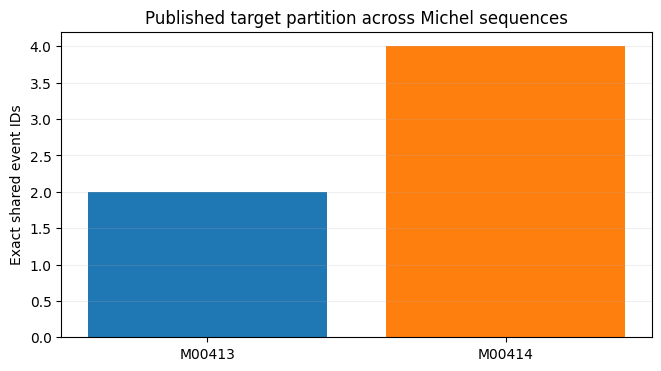

In [3]:
MICHEL = PROJECT / "outputs" / "michel_validation"
with (MICHEL / "status.json").open("r", encoding="utf-8") as handle:
    michel_status = json.load(handle)
conflicts = pd.read_csv(MICHEL / "catalog_partition_conflicts.csv")
overlap = pd.read_csv(MICHEL / "sequence_overlap_matrix.csv")
crosswalk = pd.read_csv(
    MICHEL / "exact_id_crosswalk.csv", dtype={"event_id": str}
)

display(
    pd.DataFrame(
        [
            {
                "Michel events": michel_status["catalog_event_count"],
                "Michel sequences": michel_status["catalog_sequence_count"],
                "exact-ID matches": michel_status["exact_id_match_count"],
                "partition conflicts": michel_status[
                    "partition_conflict_count"
                ],
                "binary label gate": michel_status[
                    "classification_label_gate"
                ],
            }
        ]
    )
)
display(conflicts)
display(
    crosswalk.loc[
        crosswalk["michel_exact_id_match"].astype(str).str.lower().eq("true"),
        [
            "event_id",
            "waldhauser_schaff_sequence_id",
            "waldhauser_schaff_validation_role",
            "michel_sequence_id",
            "mapping_method",
        ],
    ]
)

target_id = "R1.2900.11955.0"
target_overlap = overlap.loc[
    overlap["waldhauser_schaff_sequence_id"] == target_id
].copy()
fig, ax = plt.subplots(figsize=(6.5, 3.6), constrained_layout=True)
ax.bar(
    target_overlap["michel_sequence_id"],
    target_overlap["exact_shared_event_count"],
    color=["tab:blue", "tab:orange"],
)
ax.set_ylabel("Exact shared event IDs")
ax.set_title("Published target partition across Michel sequences")
ax.grid(axis="y", alpha=0.2)
plt.show()

## 2. What the conventional array can and cannot resolve

The comparison below uses the mapped historical M00413/M00414 events and the same full conventional array used by the frozen verifier. “Within” and “between” refer to the Michel partition. Pair rows are useful diagnostics but are not independent statistical samples because events recur across pairs.

Correlation is worse than random-direction ranking for this partition (AUC 0.417). Station-centered differential lag is only modestly informative (AUC 0.630), and an event bootstrap is not identifiable with only two historical M00413 events. This is a fair comparator and a strong motivation for testing DAS spatial information—not proof that DAS wins.

,allowed_interpretation,between_pair_count,conventional_partition_separation_claim,correlation_pair_auc_within_vs_between,differential_lag_pair_auc_within_vs_between,generated_utc,mapped_event_count,mapped_event_ids,reason,status,uncertainty_status,within_pair_count
0,comparator diagnostic motivating a held-out DA...,12,STOP,0.416667,0.630208,2026-08-15T18:57:43Z,8,"[40220017, 40237728, 51214531, 71325295, 71567...",diagnostic pair distributions overlap and labe...,STOP,event_block_bootstrap_not_identifiable_with_tw...,16


,pair_count,median_correlation,median_lag_rms_ms
relation,,,
between M00413/M00414,12,0.989278,4.493945
within Michel sequence,16,0.985245,3.276721


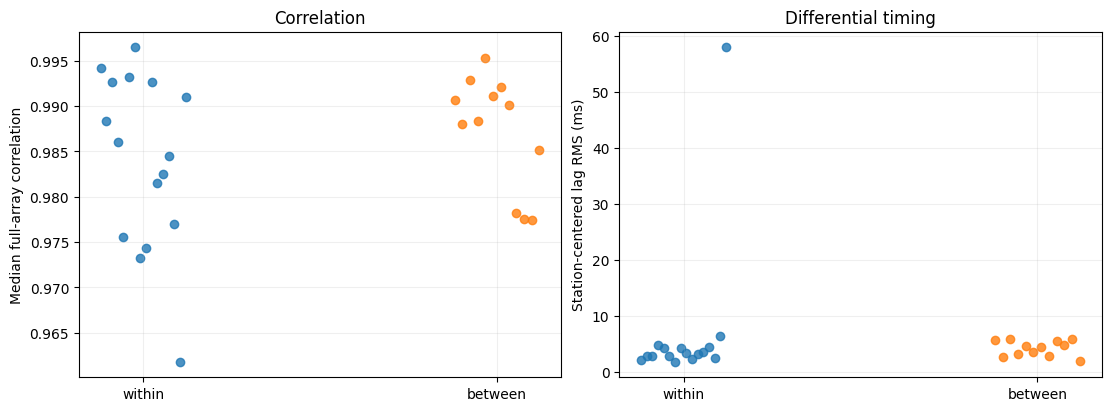

In [4]:
PARTITION = MICHEL / "partition_diagnostic"
with (PARTITION / "status.json").open("r", encoding="utf-8") as handle:
    partition_status = json.load(handle)
pair_partition = pd.read_csv(
    PARTITION / "network_pair_partition_features.csv"
)
pair_partition["relation"] = np.where(
    pair_partition["partition_relation"].str.startswith("within"),
    "within Michel sequence",
    "between M00413/M00414",
)

display(pd.DataFrame([partition_status]))
display(
    pair_partition.groupby("relation").agg(
        pair_count=("reference_event_id", "size"),
        median_correlation=("median_correlation", "median"),
        median_lag_rms_ms=("differential_lag_rms_s", lambda x: 1000 * x.median()),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
order = ["within Michel sequence", "between M00413/M00414"]
colors = ["tab:blue", "tab:orange"]
for index, (label, color) in enumerate(zip(order, colors)):
    group = pair_partition.loc[pair_partition["relation"] == label]
    jitter = np.linspace(-0.12, 0.12, len(group))
    axes[0].scatter(
        np.full(len(group), index) + jitter,
        group["median_correlation"],
        color=color,
        alpha=0.8,
    )
    axes[1].scatter(
        np.full(len(group), index) + jitter,
        1000 * group["differential_lag_rms_s"],
        color=color,
        alpha=0.8,
    )
axes[0].set_ylabel("Median full-array correlation")
axes[1].set_ylabel("Station-centered lag RMS (ms)")
for ax, title in zip(
    axes,
    ["Correlation", "Differential timing"],
):
    ax.set_xticks([0, 1], ["within", "between"])
    ax.set_title(title)
    ax.grid(alpha=0.2)
plt.show()

## 3. Frozen network verifier and threshold sandbox

Version 1 was fit on 12 historical exact-ID events before prospective waveform access. It uses two gates: median target-anchor correlation must be high, and station-centered differential-lag RMS must be low. Historical balanced accuracy is training performance, not held-out accuracy.

Set either exploratory control in the first cell to a number to see what moves. The table and figure will update, but no JSON/CSV model is changed. Because prospective outcomes are already visible, any new rule would require a version 2 and a new split.

Frozen model SHA256: bf6dfbd36ecf44721245dfb237b7bb36587d3cdb22dd0d03c4f835d9048357c3
Using frozen thresholds: True
Correlation threshold: 0.966109158079069
Lag-RMS threshold (s): 0.012012057489268927


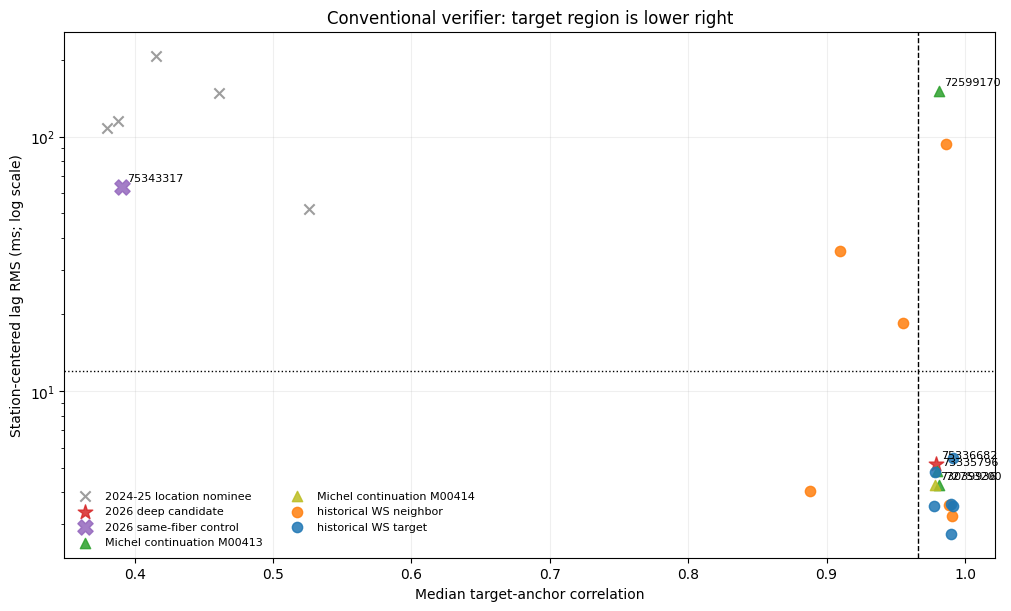

,event_id,population,median_target_correlation,median_target_differential_lag_rms_s,frozen_decision,sandbox_decision
20,75021072,2024-25 location nominee,0.460850,0.147655,not_target_family,not_target_family_or_abstain
19,75120101,2024-25 location nominee,0.387896,0.114930,not_target_family,not_target_family_or_abstain
18,75120116,2024-25 location nominee,0.379788,0.108356,not_target_family,not_target_family_or_abstain
21,75153522,2024-25 location nominee,0.415470,0.208044,not_target_family,not_target_family_or_abstain
22,75162676,2024-25 location nominee,0.525974,0.052028,not_target_family,not_target_family_or_abstain
27,75336682,2026 deep candidate,0.978975,0.005176,target_family,target_family
28,75343317,2026 same-fiber control,0.390702,0.063346,not_target_family,not_target_family_or_abstain
23,72599170,Michel continuation M00413,0.981144,0.151064,not_target_family,not_target_family_or_abstain
24,72753200,Michel continuation M00413,0.981250,0.004264,target_family,target_family
26,73335796,Michel continuation M00413,0.979732,0.004852,target_family,target_family


In [5]:
BASELINE = PROJECT / "outputs" / "incremental_value" / "network_baseline"
with (BASELINE / "network_model_frozen.json").open(
    "r", encoding="utf-8"
) as handle:
    frozen_model = json.load(handle)

correlation_threshold = (
    frozen_model["correlation_threshold"]
    if EXPLORATORY_CORRELATION_THRESHOLD is None
    else float(EXPLORATORY_CORRELATION_THRESHOLD)
)
lag_threshold_s = (
    frozen_model["differential_lag_rms_threshold_s"]
    if EXPLORATORY_LAG_RMS_THRESHOLD_S is None
    else float(EXPLORATORY_LAG_RMS_THRESHOLD_S)
)
sandbox_is_frozen = (
    EXPLORATORY_CORRELATION_THRESHOLD is None
    and EXPLORATORY_LAG_RMS_THRESHOLD_S is None
)

historical = pd.read_csv(
    BASELINE / "historical_frozen_decisions.csv", dtype={"event_id": str}
)
historical["population"] = np.where(
    historical["is_published_target"].astype(str).str.lower().eq("true"),
    "historical WS target",
    "historical WS neighbor",
)

prospective_rows = pd.read_csv(
    PROJECT
    / "outputs"
    / "incremental_value"
    / "prospective_network"
    / "frozen_network_decisions.csv",
    dtype={"event_id": str},
)
prospective_rows["population"] = "2024-25 location nominee"

continuation_rows = pd.read_csv(
    MICHEL / "frozen_network" / "decisions.csv", dtype={"event_id": str}
)
continuation_rows["population"] = (
    "Michel continuation " + continuation_rows["michel_sequence_id"]
)

deep_rows = pd.read_csv(
    PROJECT
    / "outputs"
    / "incremental_value"
    / "deep_named_network"
    / "decisions.csv",
    dtype={"event_id": str},
)
deep_rows["population"] = deep_rows["named_role"].map(
    {
        "prospective_deep_das_candidate": "2026 deep candidate",
        "prospective_same_fiber_hard_control": "2026 same-fiber control",
    }
)

scores = pd.concat(
    [historical, prospective_rows, continuation_rows, deep_rows],
    ignore_index=True,
    sort=False,
)
scores["sandbox_decision"] = np.where(
    scores["score_status"].eq("PASS")
    & (scores["median_target_correlation"] >= correlation_threshold)
    & (
        scores["median_target_differential_lag_rms_s"]
        <= lag_threshold_s
    ),
    "target_family",
    "not_target_family_or_abstain",
)

print("Frozen model SHA256:", checkpoint["network_model_sha256"])
print("Using frozen thresholds:", sandbox_is_frozen)
print("Correlation threshold:", correlation_threshold)
print("Lag-RMS threshold (s):", lag_threshold_s)
if not sandbox_is_frozen:
    print("EXPLORATORY ONLY: these values have seen prospective outcomes.")

style = {
    "historical WS target": ("tab:blue", "o"),
    "historical WS neighbor": ("tab:orange", "o"),
    "2024-25 location nominee": ("0.55", "x"),
    "Michel continuation M00413": ("tab:green", "^"),
    "Michel continuation M00414": ("tab:olive", "^"),
    "2026 deep candidate": ("tab:red", "*"),
    "2026 same-fiber control": ("tab:purple", "X"),
}
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for population_name, group in scores.groupby("population"):
    color, marker = style.get(population_name, ("0.3", "o"))
    ax.scatter(
        group["median_target_correlation"],
        1000 * group["median_target_differential_lag_rms_s"],
        label=population_name,
        color=color,
        marker=marker,
        s=120 if "2026" in population_name else 55,
        alpha=0.85,
    )
    if (
        "historical" not in population_name
        and "location nominee" not in population_name
    ):
        for _, row in group.iterrows():
            ax.annotate(
                row["event_id"],
                (
                    row["median_target_correlation"],
                    1000 * row["median_target_differential_lag_rms_s"],
                ),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )
ax.axvline(correlation_threshold, color="k", linestyle="--", linewidth=1)
ax.axhline(1000 * lag_threshold_s, color="k", linestyle=":", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("Median target-anchor correlation")
ax.set_ylabel("Station-centered lag RMS (ms; log scale)")
ax.set_title("Conventional verifier: target region is lower right")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.show()

display(
    scores.loc[
        ~scores["population"].str.startswith("historical"),
        [
            "event_id",
            "population",
            "median_target_correlation",
            "median_target_differential_lag_rms_s",
            "frozen_decision",
            "sandbox_decision",
        ],
    ].sort_values(["population", "event_id"])
)

## 4. The 2026 deep-fiber opportunity

The joint evidence is deliberately asymmetric. Network processing was frozen before prospective access and opened zero DAS files. Separately, the pre-existing deep-DAS pilot establishes that event 75336682 is detectable across the sampled fiber, while event 75343317 supplies a same-configuration hard control.

This is stronger than “I see an earthquake on DAS,” but it is still conditional: there is only one deep candidate, the family partition is disputed, and absolute deep geometry is unsurveyed.

,event_id,named_role,median_target_correlation,median_target_differential_lag_rms_s,frozen_decision,catalog_partition_warning
0,75336682,prospective_deep_das_candidate,0.978975,0.005176,target_family,Waldhauser-Schaff and Michel exact-ID family l...
1,75343317,prospective_same_fiber_hard_control,0.390702,0.063346,not_target_family,Waldhauser-Schaff and Michel exact-ID family l...


,event_id,role,status,peak_robust_z,median_channel_snr,detected_block_fraction,usable_power_snr_ranges_hz
0,75336682,deep_template,PASS,6.567549,3.688536,1.00000,"[[4.8828125, 38.0859375]]"
1,75343317,hard_spatial_control,PASS,5.474848,4.418270,0.96875,"[[5.859375, 38.0859375]]"


,allowed_use,channel_count,channel_snr_fingerprint_spearman,fraction_above_0_8,maximum_per_channel_correlation,maximum_residual_lag_s,median_per_channel_correlation,origin_relative_window_s,p90_per_channel_correlation,p95_per_channel_correlation,pair_role
0,negative baseline for a future preregistered D...,800,0.514722,0.0,0.618809,0.5,0.218631,"[0.5, 10.0]",0.356879,0.41366,same-fiber magnitude-matched hard negative


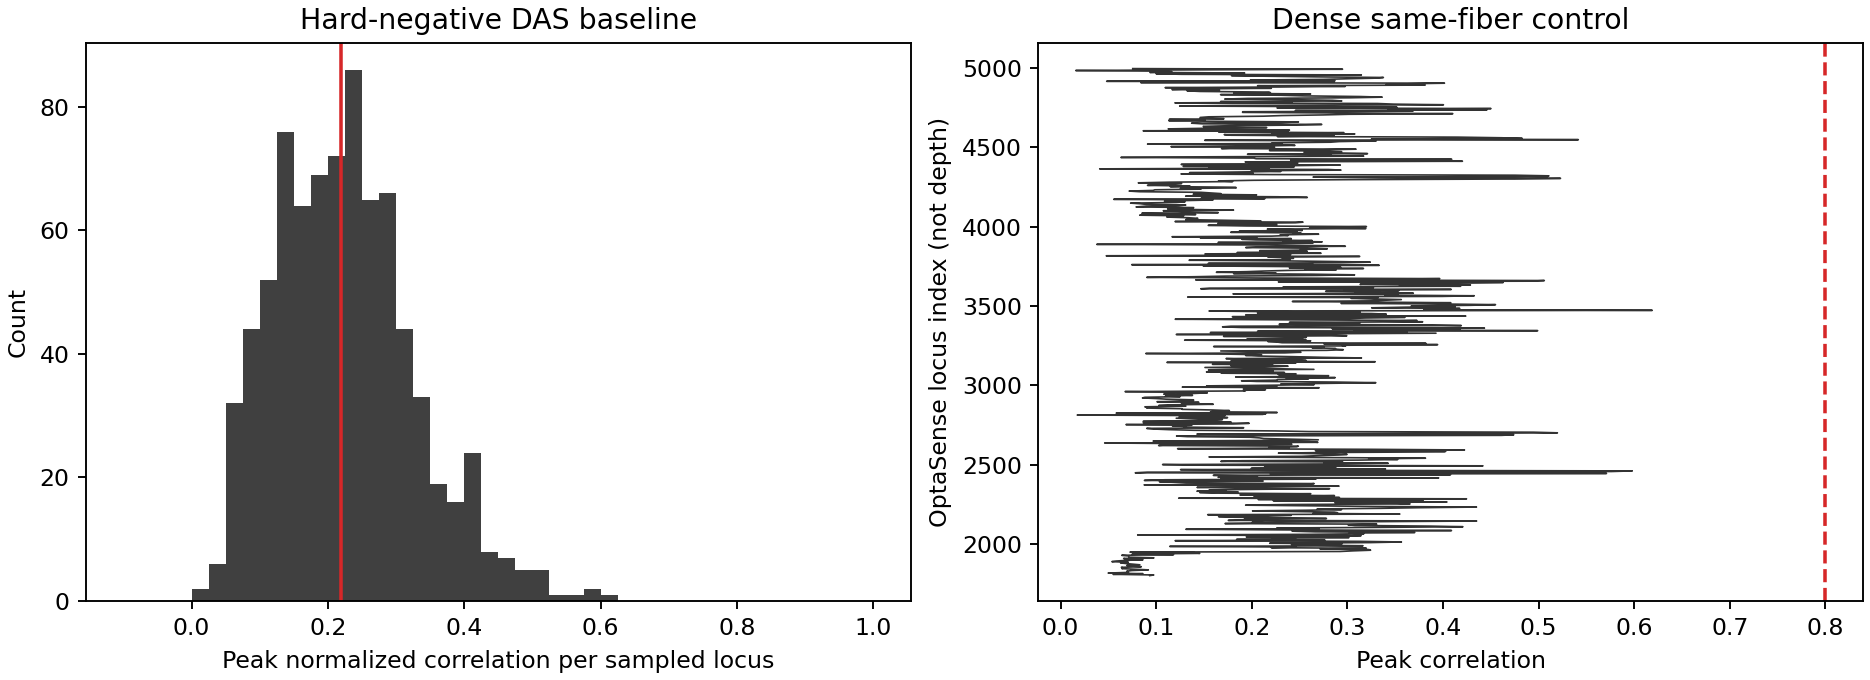

In [6]:
DEEP_DAS = PROJECT / "outputs" / "deep_das"
deep_metrics = pd.read_csv(
    DEEP_DAS / "event_metrics.csv", dtype={"event_id": str}
)
with (DEEP_DAS / "hard_negative_baseline.json").open(
    "r", encoding="utf-8"
) as handle:
    hard_negative = json.load(handle)

display(
    deep_rows[
        [
            "event_id",
            "named_role",
            "median_target_correlation",
            "median_target_differential_lag_rms_s",
            "frozen_decision",
            "catalog_partition_warning",
        ]
    ]
)
display(
    deep_metrics[
        [
            "event_id",
            "role",
            "status",
            "peak_robust_z",
            "median_channel_snr",
            "detected_block_fraction",
            "usable_power_snr_ranges_hz",
        ]
    ]
)
display(pd.DataFrame([hard_negative]))

negative_figure = DEEP_DAS / "hard_negative_baseline.png"
if negative_figure.exists():
    display(Image(filename=str(negative_figure)))
else:
    print("Optional cached figure is absent:", negative_figure)

## 5. Archive population and sealed test intervals

The archive population was built from the primary manifest and an official NCSS query. Held-out intervals were selected from DAS coverage alone before catalog joining. Five routine-catalog events were nominated only by location and coverage; all five fail the frozen network target verifier.

That negative result is useful. It prevents the project from calling every nearby routine event a repeater and shows why genuine extension requires continuous DAS-only candidate generation rather than catalog proximity.

In [7]:
INCREMENTAL = PROJECT / "outputs" / "incremental_value"
with (INCREMENTAL / "population_status.json").open(
    "r", encoding="utf-8"
) as handle:
    population_status = json.load(handle)
with (INCREMENTAL / "catalog_provenance.json").open(
    "r", encoding="utf-8"
) as handle:
    catalog_provenance = json.load(handle)

heldout = pd.read_csv(INCREMENTAL / "heldout_intervals.csv")
archive_decisions = prospective_rows[
    [
        "event_id",
        "origin_time",
        "median_target_correlation",
        "median_target_differential_lag_rms_s",
        "frozen_decision",
    ]
].copy()

display(pd.DataFrame([population_status]))
display(pd.DataFrame([catalog_provenance["manifest_stats"]]))
display(archive_decisions)
display(
    heldout[
        [
            "interval_id",
            "start_utc",
            "end_utc",
            "coverage_segment_id",
            "analysis_status",
        ]
    ]
)
print(
    "DAS waveform files opened during prospective network scoring:",
    checkpoint["guardrails"]["network_scoring_das_waveforms_opened"],
)

,candidate_event_ids,catalog_event_count,catalog_events_with_complete_primary_das_window,config_sha256,contiguous_coverage_hours,contiguous_coverage_segment_count,development_interval_event_ids,embargo_release_gate,family_label_count,family_label_rule,...,heldout_interval_count,heldout_selection_input,heldout_total_hours,longest_contiguous_segment_hours,primary_manifest_record_count,prospective_candidate_count,prospective_network_waveform_access,release_model_path,stage,status
0,"[75120116, 75120101, 75021072, 75153522, 75162...",404,266,7da34f8f8353ce39ab6f2b44246937d04583b9f8354dc0...,6297.382589,123,"[75120116, 75120101]",network_model_frozen.json exists and its hashe...,0,catalog_proximity_never_assigns_family_membership,...,12,DAS_manifest_only_blind_to_catalog_and_wavefor...,12.0,1941.177492,378050,5,RELEASED_FOR_BLIND_NETWORK_SCORING,/home/groups/ettore88/nberrios/safod_das_git/n...,prospective_population_constructed_waveform_ac...,CONDITIONAL


,manifest_rows,path_rewrite_count,placeholder_or_numeric_invalid_rows,primary_configuration_time_valid_rows,primary_configuration_timestamp_invalid_rows,timestamp_invalid_rows,valid_other_configuration_rows
0,392095,1,16,378050,1,1,14028


,event_id,origin_time,median_target_correlation,median_target_differential_lag_rms_s,frozen_decision
0,75120116,2025-01-20T05:24:29.130Z,0.379788,0.108356,not_target_family
1,75120101,2025-01-20T05:14:48.490Z,0.387896,0.114930,not_target_family
2,75021072,2024-06-12T01:58:45.580Z,0.460850,0.147655,not_target_family
3,75153522,2025-03-23T00:02:18.260Z,0.415470,0.208044,not_target_family
4,75162676,2025-04-10T01:01:44.360Z,0.525974,0.052028,not_target_family


,interval_id,start_utc,end_utc,coverage_segment_id,analysis_status
0,heldout_01,2024-05-27T16:52:37.448Z,2024-05-27T17:52:37.448Z,6,SEALED_NOT_RUN
1,heldout_02,2024-06-12T21:57:21.083Z,2024-06-12T22:57:21.083Z,20,SEALED_NOT_RUN
2,heldout_03,2024-06-16T03:19:11.909Z,2024-06-16T04:19:11.909Z,20,SEALED_NOT_RUN
3,heldout_04,2024-06-18T12:09:53.565Z,2024-06-18T13:09:53.565Z,20,SEALED_NOT_RUN
4,heldout_05,2024-12-25T05:11:40.832Z,2024-12-25T06:11:40.832Z,109,SEALED_NOT_RUN
5,heldout_06,2025-01-03T03:54:15.472Z,2025-01-03T04:54:15.472Z,109,SEALED_NOT_RUN
6,heldout_07,2025-01-27T01:33:30.406Z,2025-01-27T02:33:30.406Z,109,SEALED_NOT_RUN
7,heldout_08,2025-02-18T07:21:08.087Z,2025-02-18T08:21:08.087Z,113,SEALED_NOT_RUN
8,heldout_09,2025-03-18T14:59:11.634Z,2025-03-18T15:59:11.634Z,113,SEALED_NOT_RUN
9,heldout_10,2025-03-30T20:53:34.987Z,2025-03-30T21:53:34.987Z,113,SEALED_NOT_RUN


DAS waveform files opened during prospective network scoring: 0


## 6. Next experiment and review decision points

The 50-minute development interval is intentionally nonblind. Its purpose is to make each detector operational and freeze its false-discovery controls—not to estimate final performance. The 12 sealed hours are opened only after both candidate generators and adjudication rules are frozen.

In [8]:
next_experiment = pd.DataFrame(
    [
        {
            "order": 1,
            "deliverable": "Network-only continuous detector",
            "development input": "2025-01-20 04:55--05:45 UTC (50 minutes)",
            "information allowed": "network waveforms and historical templates only",
            "pass to continue": "frozen candidate table plus empirical event-level FDR",
        },
        {
            "order": 2,
            "deliverable": "DAS-only continuous detector",
            "development input": "the identical 50-minute interval",
            "information allowed": "DAS waveforms only; no network trigger times",
            "pass to continue": "frozen candidate table plus channel/block null controls",
        },
        {
            "order": 3,
            "deliverable": "Blind union adjudication",
            "development input": "deduplicated candidates",
            "information allowed": "candidate identity hidden",
            "pass to continue": "frozen event definition and ambiguity/abstention rules",
        },
        {
            "order": 4,
            "deliverable": "Held-out comparison",
            "development input": "12 sealed one-hour intervals",
            "information allowed": "both frozen pipelines",
            "pass to continue": "positive interval-bootstrap lower bound at matched FDR",
        },
    ]
)
display(next_experiment)
display(pd.DataFrame(checkpoint["project_shape"]))
print("Next analysis:", checkpoint["highest_value_next_analysis"])
print("Best next observation:", checkpoint["highest_value_next_observation"])
print("Metadata request:", checkpoint["highest_value_metadata_request"])

,order,deliverable,development input,information allowed,pass to continue
0,1,Network-only continuous detector,2025-01-20 04:55--05:45 UTC (50 minutes),network waveforms and historical templates only,frozen candidate table plus empirical event-le...
1,2,DAS-only continuous detector,the identical 50-minute interval,DAS waveforms only; no network trigger times,frozen candidate table plus channel/block null...
2,3,Blind union adjudication,deduplicated candidates,candidate identity hidden,frozen event definition and ambiguity/abstenti...
3,4,Held-out comparison,12 sealed one-hour intervals,both frozen pipelines,positive interval-bootstrap lower bound at mat...


,aim,current_status,question
0,Aim 1: family-partition resolution,READY_FOR_DAS_FEATURE_DEVELOPMENT,Can deep near-source DAS distinguish M00413 fr...
1,Aim 2: catalog extension,HELDOUT_NETWORK_REGISTERED_RUNNER_IMPLEMENTATI...,Does a DAS-only or joint continuous scan recov...
2,Aim 3: source physics and creep,DOWNSTREAM_STOP,Can validated repeated events constrain relati...


Next analysis: implement, test, commit, and push the registered held-out network runner, then execute all 12 hours before any held-out DAS access
Best next observation: another independently network-classified event on the same deep DAS configuration
Metadata request: surveyed deep channel-to-MD/TVD/XYZ/cable-leg/tangent mapping


## 7. Source physics remains downstream

The deep audit supports channel spacing and a channel-1702 hairpin convention, not a surveyed channel-to-MD/TVD/XYZ/tangent trajectory. Therefore this checkpoint makes no absolute depth, source-distance, directivity, rupture-radius, stress-drop, or slip-rate claim.

A stress-drop branch becomes defensible only after there are at least two independently adjudicated same-configuration events, response and timing are audited, a same-path EGF ensemble exists, spectral corners lie inside the empirical usable band, and geometry/model/synthetic tests pass. A creep-rate branch additionally needs a complete recurrence population and constrained event slip.

In [9]:
source_gates = branches.loc[
    branches["branch"].isin(
        [
            "Deep channel geometry",
            "Relative source size / stress drop",
            "Repeater-derived creep rate",
        ]
    ),
    ["branch", "status", "evidence", "next_gate"],
]
display(source_gates)

if REBUILD_COMPACT_CHECKPOINT:
    print("Compact checkpoint JSON/CSV regenerated; no raw data were opened.")
else:
    print("Cached-only review session complete.")

,branch,status,evidence,next_gate
8,Deep channel geometry,STOP,channel spacing and a channel-1702 hairpin con...,obtain or reconstruct a surveyed geometry tabl...
13,Relative source size / stress drop,STOP,no same-epoch independently classified EGF pai...,"response audit, same-path EGF ensemble, in-ban..."
14,Repeater-derived creep rate,STOP,"family membership, continuous completeness, ev...",attempt only after a validated DAS-assisted fa...


Cached-only review session complete.
